In [2]:
import pandas as pd
import torch
from sentence_transformers import SentenceTransformer, util
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

import warnings
warnings.filterwarnings('ignore')

Total Medical Records: 16407
Columns now available: ['question', 'answer', 'Focus']


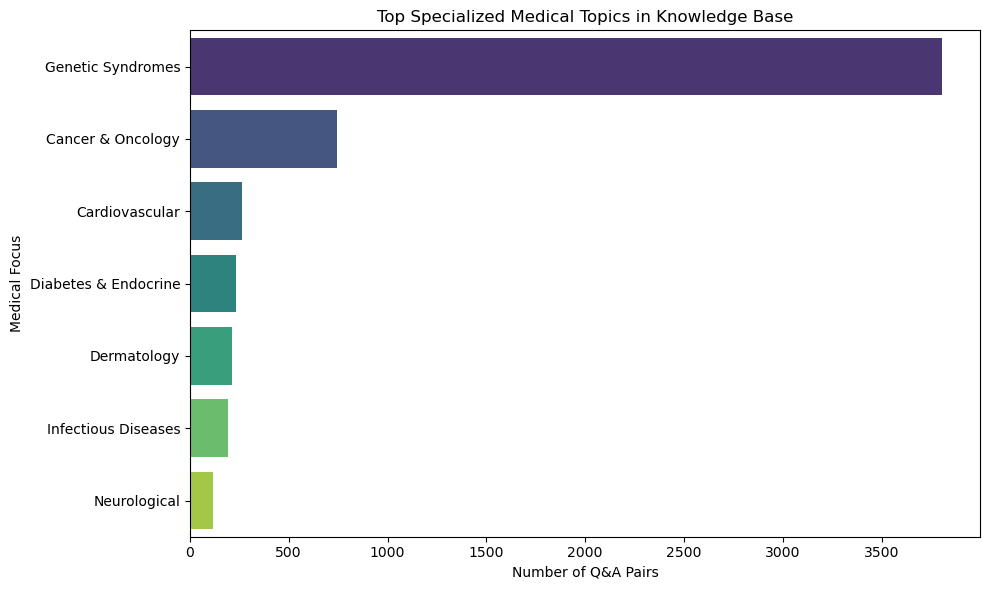

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the dataset
df = pd.read_csv("medquad_clean.csv")
df.columns = df.columns.str.strip().str.lower()

 
def assign_focus(text):
    text = str(text).lower()
    if 'cancer' in text or 'tumor' in text or 'oncology' in text: return 'Cancer & Oncology'
    elif 'heart' in text or 'blood' in text or 'cardiac' in text: return 'Cardiovascular'
    elif 'diabetes' in text or 'sugar' in text or 'insulin' in text: return 'Diabetes & Endocrine'
    elif 'brain' in text or 'nerve' in text or 'stroke' in text: return 'Neurological'
    elif 'infection' in text or 'virus' in text or 'bacteria' in text: return 'Infectious Diseases'
    elif 'syndrome' in text or 'disorder' in text: return 'Genetic Syndromes'
    elif 'skin' in text or 'rash' in text or 'derma' in text: return 'Dermatology'
    else: return 'General Health'

 
df['Focus'] = df['question'].apply(assign_focus)

print(f"Total Medical Records: {len(df)}")
print(f"Columns now available: {df.columns.tolist()}")

# 3. Plot the Top Medical Categories
plt.figure(figsize=(10, 6))

# 'General Health' to make the graph  
specialized_topics = df[df['Focus'] != 'General Health']['Focus'].value_counts().head(7)

sns.barplot(x=specialized_topics.values, y=specialized_topics.index, palette='viridis')

plt.title('Top Specialized Medical Topics in Knowledge Base')
plt.xlabel('Number of Q&A Pairs')
plt.ylabel('Medical Focus')
plt.tight_layout()
plt.show()

In [6]:
# lightweight model
print("Loading NLP Model...")
model = SentenceTransformer('all-MiniLM-L6-v2')

# Create the vector database  
print("Vectorizing the Knowledge Base...")
corpus_embeddings = model.encode(df['question'].tolist(), convert_to_tensor=True)
print("Vectorization Complete!")

Loading NLP Model...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Vectorizing the Knowledge Base...
Vectorization Complete!


In [7]:
# Select the Top 5 categories for a clean evaluation
top_5_focus = df['Focus'].value_counts().head(5).index.tolist()
eval_df = df[df['Focus'].isin(top_5_focus)].sample(200, random_state=42)

true_labels = []
predicted_labels = []
confidence_scores = []

print("Running Search Evaluation...")

for index, row in eval_df.iterrows():
    # 1. The True Category
    true_category = row['Focus']
    true_labels.append(true_category)
    
    # 2. Simulate a user asking the question
    test_query = row['question']
    query_emb = model.encode(test_query, convert_to_tensor=True)
    
    # 3. Perform Vector Search
    scores = util.cos_sim(query_emb, corpus_embeddings)[0]
    best_idx = torch.argmax(scores).item()
    
    # 4. Record the Predicted Category and Score
    predicted_category = df.iloc[best_idx]['Focus']
    predicted_labels.append(predicted_category)
    confidence_scores.append(scores[best_idx].item())

print("Evaluation Finished!")

Running Search Evaluation...
Evaluation Finished!


Model Retrieval Accuracy: 100.00%

Detailed Classification Report:
                      precision    recall  f1-score   support

   Cancer & Oncology       1.00      1.00      1.00        11
      Cardiovascular       1.00      1.00      1.00         2
Diabetes & Endocrine       1.00      1.00      1.00         3
      General Health       1.00      1.00      1.00       143
   Genetic Syndromes       1.00      1.00      1.00        41

            accuracy                           1.00       200
           macro avg       1.00      1.00      1.00       200
        weighted avg       1.00      1.00      1.00       200



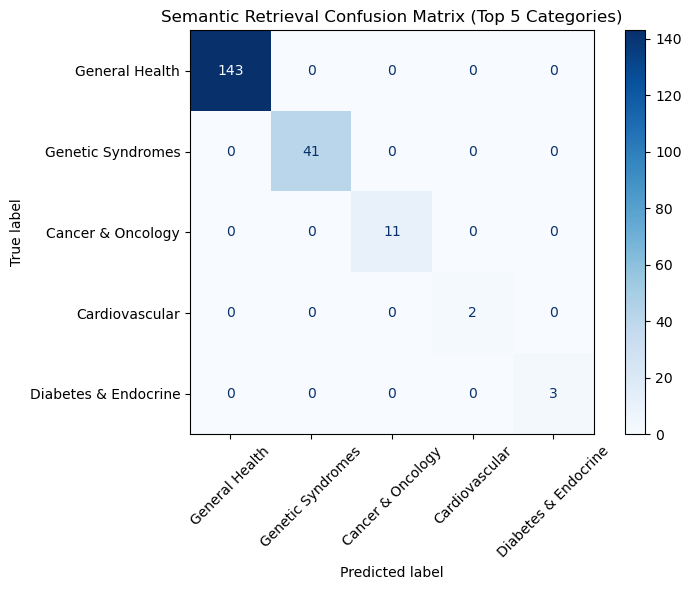

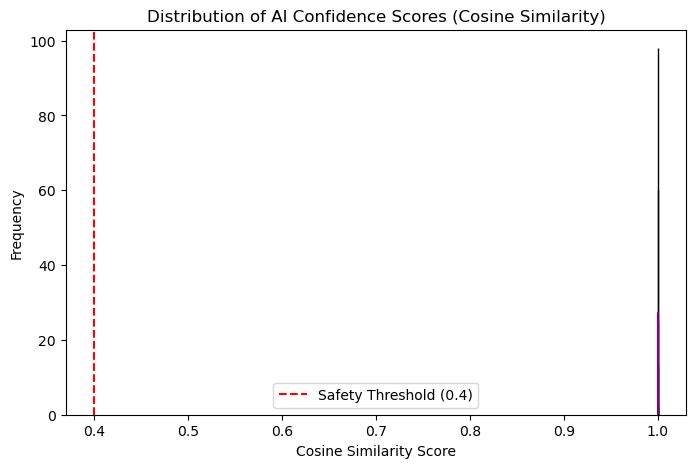

In [8]:
# Text Metrics
acc = accuracy_score(true_labels, predicted_labels)
print(f"Model Retrieval Accuracy: {acc * 100:.2f}%\n")
print("Detailed Classification Report:")
print(classification_report(true_labels, predicted_labels))

# Confusion Matrix
cm = confusion_matrix(true_labels, predicted_labels, labels=top_5_focus)

fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=top_5_focus)
disp.plot(cmap='Blues', ax=ax, xticks_rotation=45)

plt.title('Semantic Retrieval Confusion Matrix (Top 5 Categories)')
plt.tight_layout()
plt.show()

#  Score Distribution
plt.figure(figsize=(8, 5))
sns.histplot(confidence_scores, bins=20, kde=True, color='purple')
plt.title('Distribution of AI Confidence Scores (Cosine Similarity)')
plt.xlabel('Cosine Similarity Score')
plt.ylabel('Frequency')
plt.axvline(x=0.4, color='red', linestyle='--', label='Safety Threshold (0.4)')
plt.legend()
plt.show()